## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [2]:
# %pip install scipy
# %pip install scikit-learn

In [3]:
# # Перезапуск kernel ядра
# import os
# os._exit(0)

In [4]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [5]:
#fixme: Путь
dataset_dir_path = Path('D:/Universitet/5 Kurs/3 Semestr/АиП временных рядов методами ИИ/2026-Rakhimyanov-TimeSeriesCourse/practice/03 Discords/datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

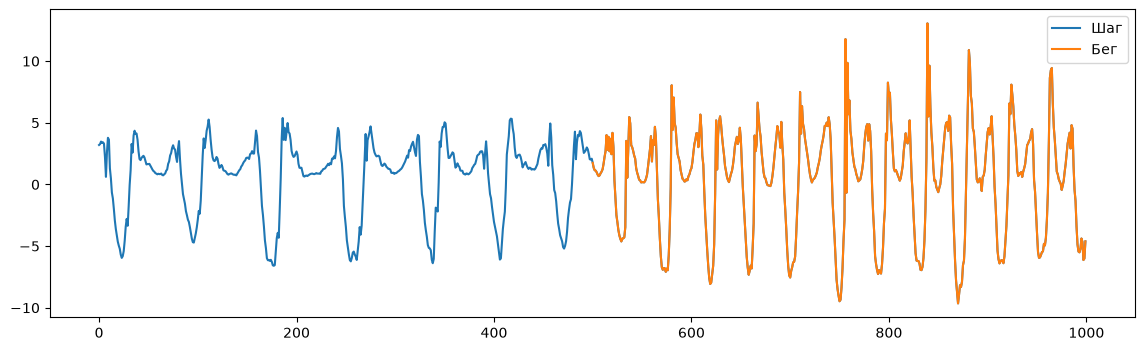

In [6]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [7]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [8]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

times['brute_force'] = end - start
result['brute_force'] = discords_brute_force

print(f'Время работы полного перебора: {times["brute_force"]:.4f} сек')

Время работы полного перебора: 80.6012 сек


##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [9]:
from modules.saxpy.hotsax import find_discords_hotsax

start = time()
discords_hotsax = np.stack(find_discords_hotsax(data[:], 50, 5))
end = time()

times['hotsax'] = end - start
result['hotsax'] = discords_hotsax

print(f'Время работы HotSAX: {times["hotsax"]:.4f} сек')

Время работы HotSAX: 1.8687 сек


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

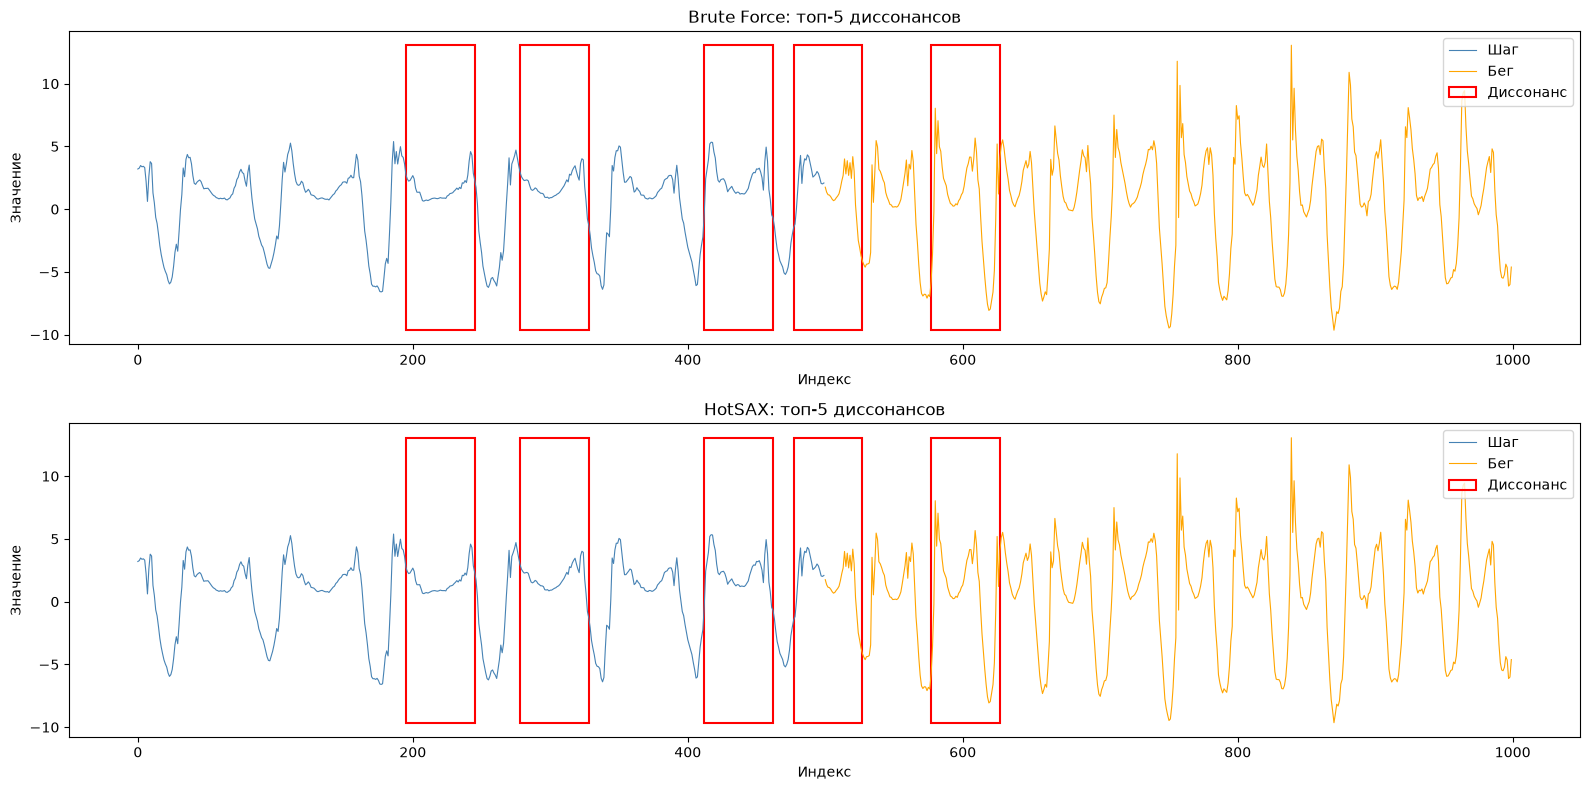

In [10]:
def plot_discords(ax, series, discords, title, size_sub=50):
    half = series.shape[0] // 2
    
    # Рисуем ряд двумя частями с разными цветами
    ax.plot(np.arange(half), series[:half],
            color='steelblue', linewidth=0.8, label='Шаг')
    ax.plot(np.arange(half, series.shape[0]), series[half:],
            color='orange', linewidth=0.8, label='Бег')
    
    # Рисуем прямоугольники диссонансов
    for i, (pos, dist) in enumerate(discords):
        ax.add_patch(Rectangle(
            (pos, series.min()),
            size_sub,
            series.max() - series.min(),
            linewidth=1.5,
            edgecolor='red',
            facecolor='none',
            label='Диссонанс' if i == 0 else None
        ))
    
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Значение')


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 8))

plot_discords(axes[0], data, discords_brute_force,
              'Brute Force: топ-5 диссонансов')
plot_discords(axes[1], data, discords_hotsax,
              'HotSAX: топ-5 диссонансов')

plt.tight_layout()
plt.show()

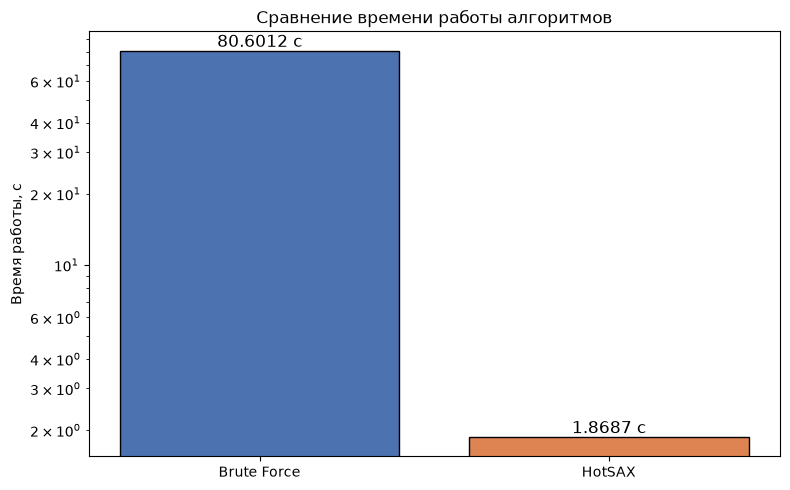

Ускорение HotSAX относительно Brute Force: 43.1x


In [11]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 5))

algorithms = ['Brute Force', 'HotSAX']
values = [times['brute_force'], times['hotsax']]
colors = ['#4C72B0', '#DD8452']

bars = ax.bar(algorithms, values, color=colors, edgecolor='black')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{val:.4f} с',
            ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Время работы, с')
ax.set_title('Сравнение времени работы алгоритмов')
ax.set_yscale('log')  # логарифмическая шкала — разница может быть огромной
plt.tight_layout()
plt.show()

print(f'Ускорение HotSAX относительно Brute Force: '
      f'{times["brute_force"] / times["hotsax"]:.1f}x')

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

Brute Force: 1777.3773 с
HotSAX:      7.9626 с
Ускорение:   223.2x


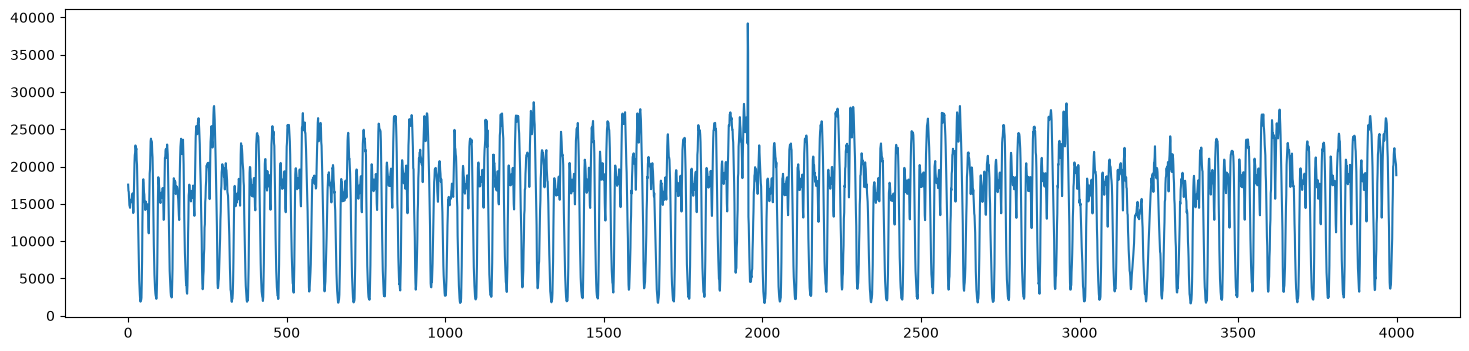

In [12]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

# Ряд такси NY
m_taxi = 50
top_k = 5

# Brute force
start = time()
discords_taxi_bf = np.stack(find_discords_brute_force(nyc_taxi, m_taxi, top_k))
end = time()
time_taxi_bf = end - start

# HotSAX
start = time()
discords_taxi_hs = np.stack(find_discords_hotsax(nyc_taxi, m_taxi, top_k))
end = time()
time_taxi_hs = end - start

print(f'Brute Force: {time_taxi_bf:.4f} с')
print(f'HotSAX:      {time_taxi_hs:.4f} с')
print(f'Ускорение:   {time_taxi_bf / time_taxi_hs:.1f}x')

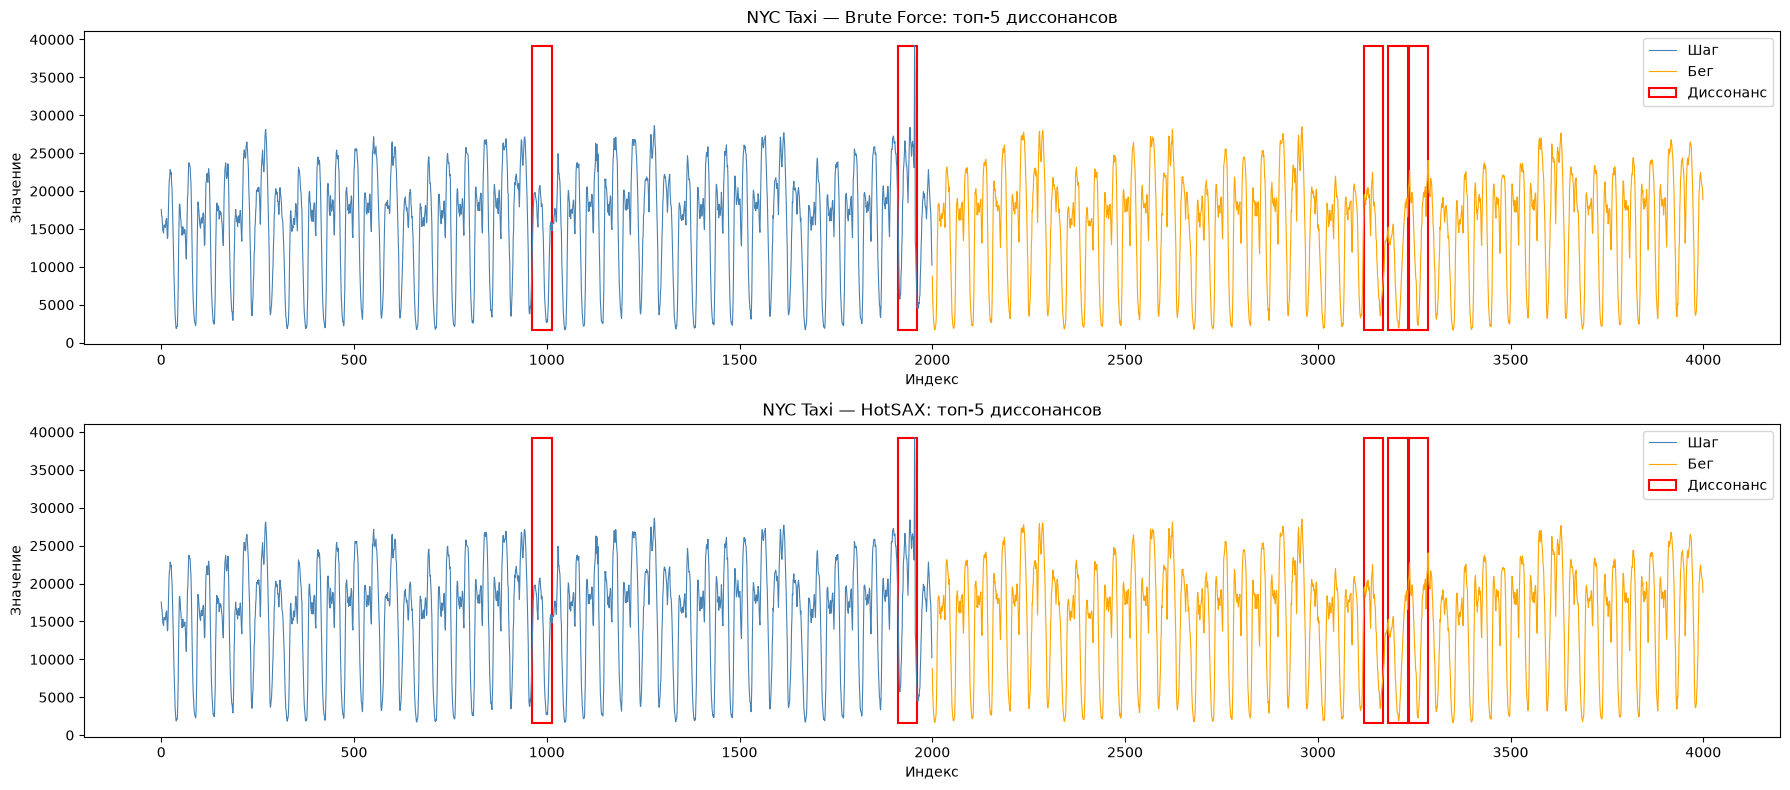

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 8))

plot_discords(axes[0], nyc_taxi, discords_taxi_bf,
              'NYC Taxi — Brute Force: топ-5 диссонансов')
plot_discords(axes[1], nyc_taxi, discords_taxi_hs,
              'NYC Taxi — HotSAX: топ-5 диссонансов')

plt.tight_layout()
plt.show()

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [14]:
%pip install stumpy==1.11.1

Note: you may need to restart the kernel to use updated packages.


In [15]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


c:\Users\RKKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\stumpy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [16]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [17]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [18]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [19]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

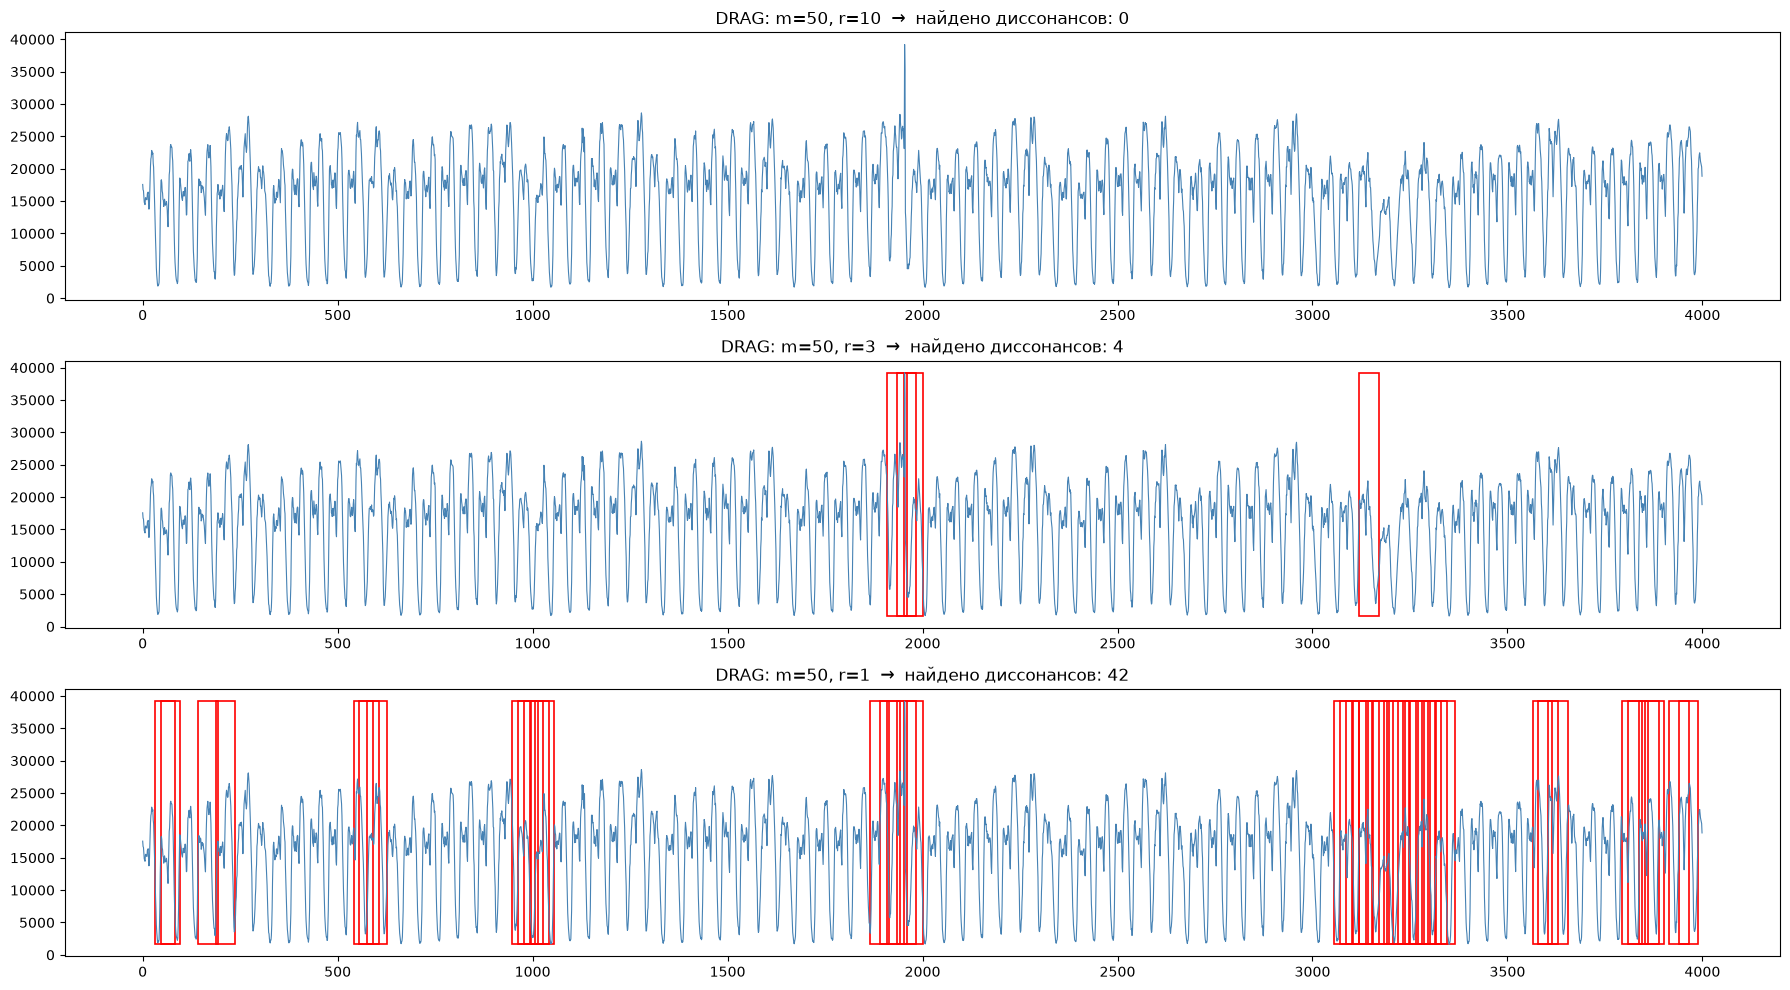

In [20]:
# Эксперименты с NYC Taxi
m = 50

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 10))
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)

for ax, r in zip(axes, [10, 3, 1]):
    idxs, _, _ = DRAG(nyc_taxi, m, r)
    ax.plot(nyc_taxi, color='steelblue', linewidth=0.8)
    for pos in idxs:
        ax.add_patch(Rectangle(
            (pos, nyc_taxi.min()),
            m,
            nyc_taxi.max() - nyc_taxi.min(),
            linewidth=1.2,
            edgecolor='red',
            facecolor='none'
        ))
    ax.set_title(f'DRAG: m={m}, r={r}  →  найдено диссонансов: {len(idxs)}')

plt.tight_layout()
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [21]:
#выбирем более реальное значение для порога
r = 3

In [22]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [23]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

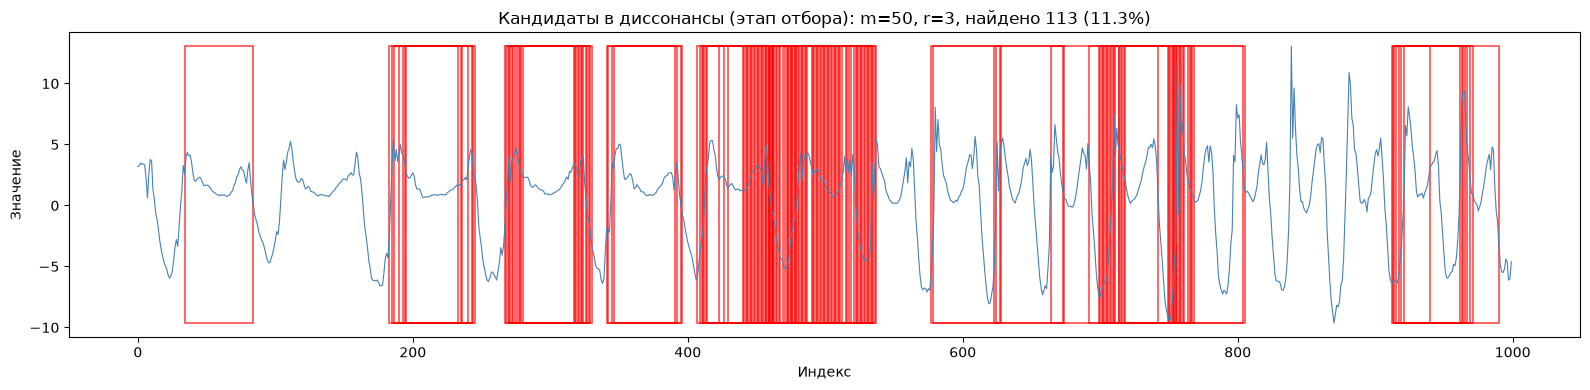

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(data, color='steelblue', linewidth=0.8, label='Ряд')

# кандидаты — прямоугольники
for pos in cand_index:
    ax.add_patch(Rectangle(
        (pos, data.min()),
        m,
        data.max() - data.min(),
        linewidth=1.2,
        edgecolor='red',
        facecolor='none',
        alpha=0.7
    ))

ax.set_title(f'Кандидаты в диссонансы (этап отбора): m={m}, r={r}, '
             f'найдено {len(cand_index)} ({len(cand_index)/len(data)*100:.1f}%)')
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [25]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [26]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

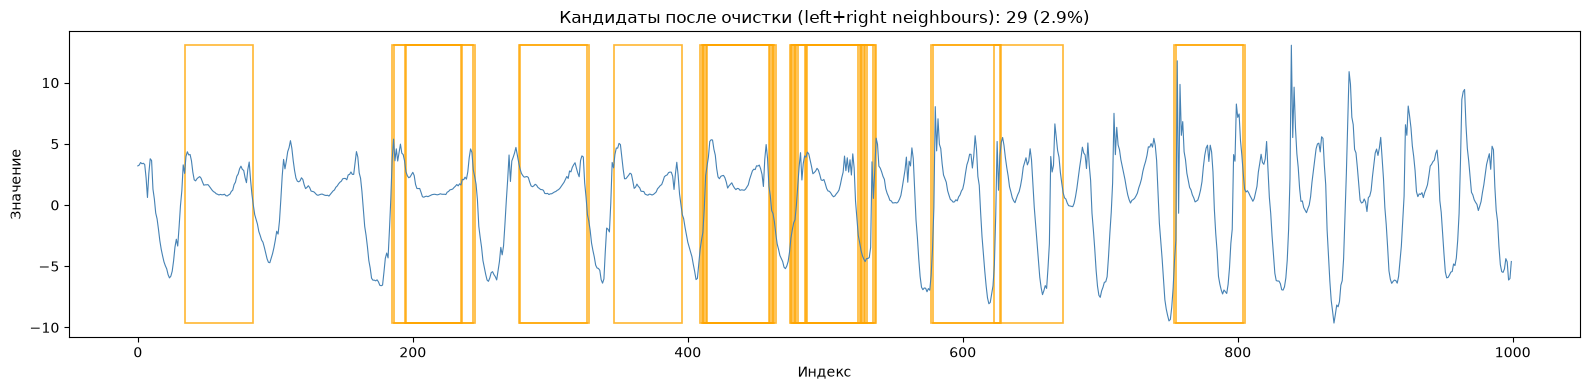

In [27]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(data, color='steelblue', linewidth=0.8, label='Ряд')

for pos in cands:
    ax.add_patch(Rectangle(
        (pos, data.min()),
        m,
        data.max() - data.min(),
        linewidth=1.2,
        edgecolor='orange',
        facecolor='none',
        alpha=0.8
    ))

ax.set_title(f'Кандидаты после очистки (left+right neighbours): '
             f'{len(cands)} ({len(cands)/len(data)*100:.1f}%)')
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [28]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

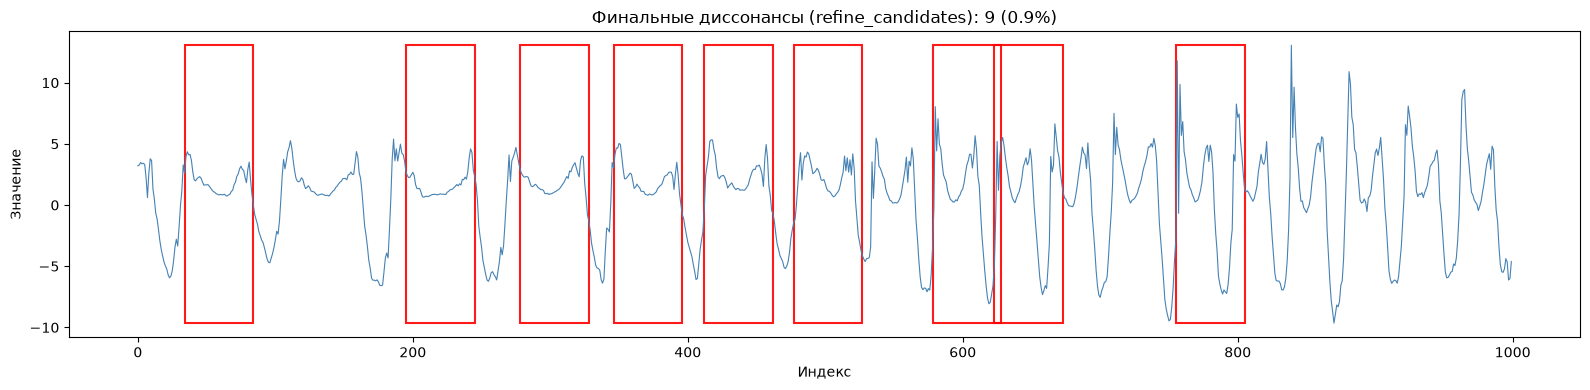

In [29]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(data, color='steelblue', linewidth=0.8, label='Ряд')

for pos in discords_idx:
    ax.add_patch(Rectangle(
        (pos, data.min()),
        m,
        data.max() - data.min(),
        linewidth=1.5,
        edgecolor='red',
        facecolor='none',
        alpha=0.9
    ))

ax.set_title(f'Финальные диссонансы (refine_candidates): '
             f'{len(discords_idx)} ({len(discords_idx)/len(data)*100:.1f}%)')
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


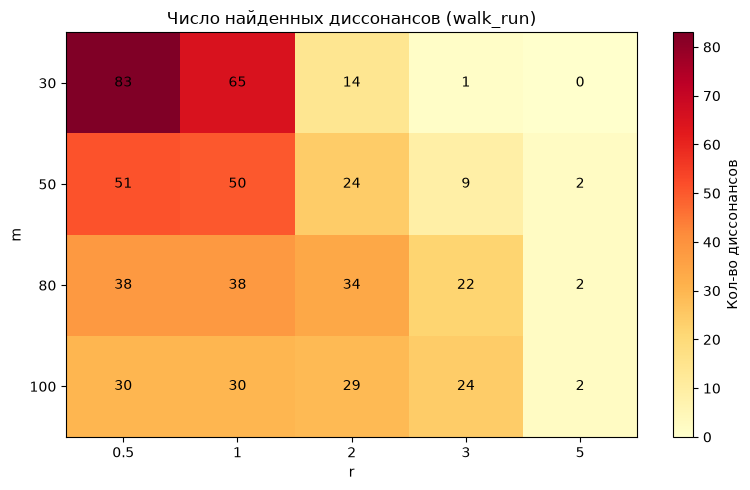

In [30]:
def run_drag_experiment(series, m_values, r_values, ax_grid=None):
    """Прогоняет DRAG по сетке (m, r) и возвращает матрицу числа диссонансов."""
    counts = np.zeros((len(m_values), len(r_values)), dtype=int)
    for i, m_ in enumerate(m_values):
        for j, r_ in enumerate(r_values):
            idxs, _, _ = DRAG(series, m_, r_)
            counts[i, j] = len(idxs)
    return counts


m_values = [30, 50, 80, 100]
r_values = [0.5, 1, 2, 3, 5]

counts = run_drag_experiment(data, m_values, r_values)

# Тепловая карта
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(counts, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(r_values)))
ax.set_xticklabels(r_values)
ax.set_yticks(range(len(m_values)))
ax.set_yticklabels(m_values)
ax.set_xlabel('r')
ax.set_ylabel('m')
ax.set_title('Число найденных диссонансов (walk_run)')

for i in range(len(m_values)):
    for j in range(len(r_values)):
        ax.text(j, i, counts[i, j], ha='center', va='center',
                color='black', fontsize=10)

plt.colorbar(im, ax=ax, label='Кол-во диссонансов')
plt.tight_layout()
plt.show()

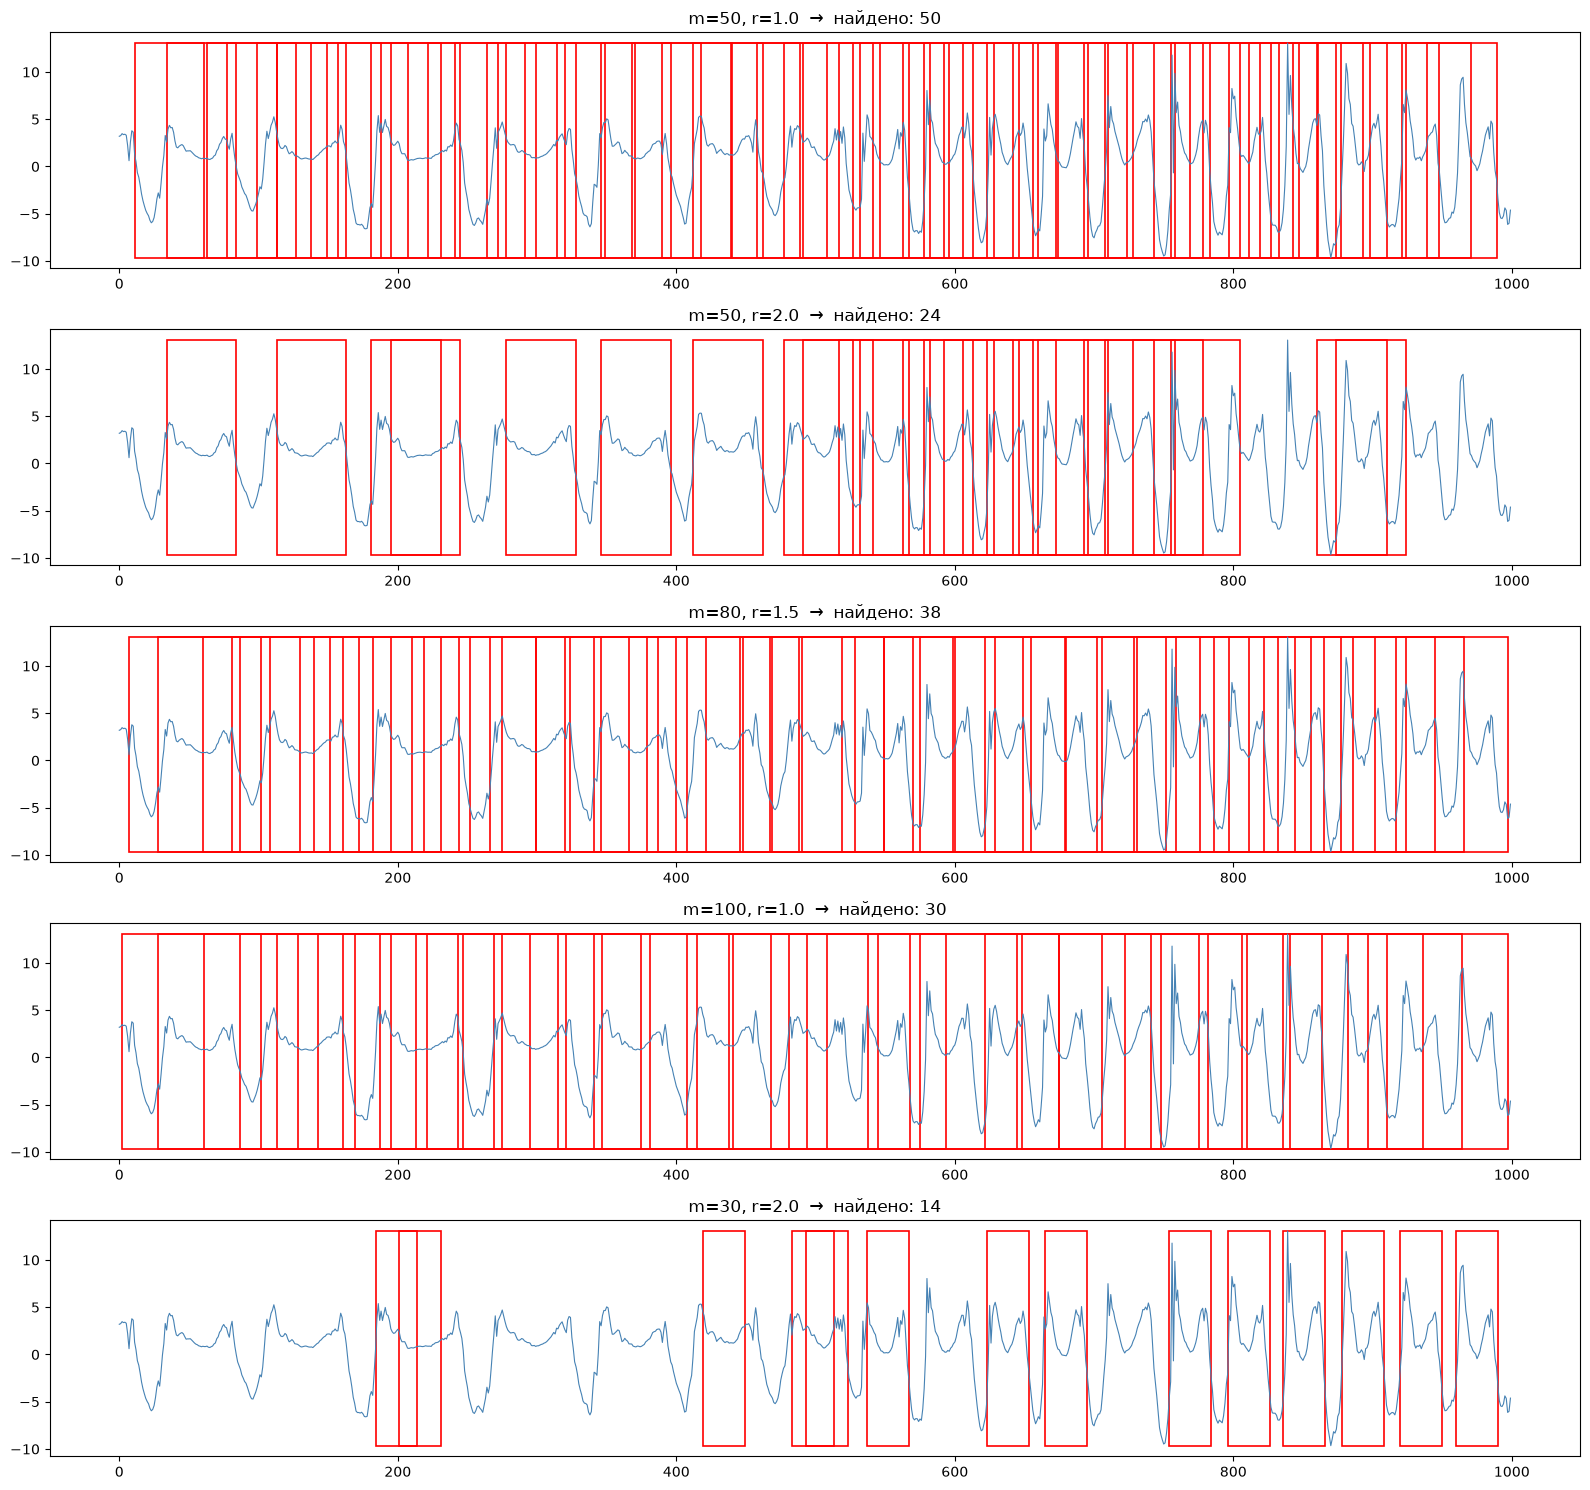

In [31]:
# Выберем несколько «интересных» комбинаций вручную
combos = [(50, 1.0), (50, 2.0), (80, 1.5), (100, 1.0), (30, 2.0)]

fig, axes = plt.subplots(nrows=len(combos), ncols=1,
                         figsize=(16, 3 * len(combos)))

for ax, (m_, r_) in zip(axes, combos):
    idxs, _, _ = DRAG(data, m_, r_)
    ax.plot(data, color='steelblue', linewidth=0.8)
    for pos in idxs:
        ax.add_patch(Rectangle(
            (pos, data.min()), m_,
            data.max() - data.min(),
            linewidth=1.2, edgecolor='red', facecolor='none'
        ))
    ax.set_title(f'm={m_}, r={r_}  →  найдено: {len(idxs)}')

plt.tight_layout()
plt.show()

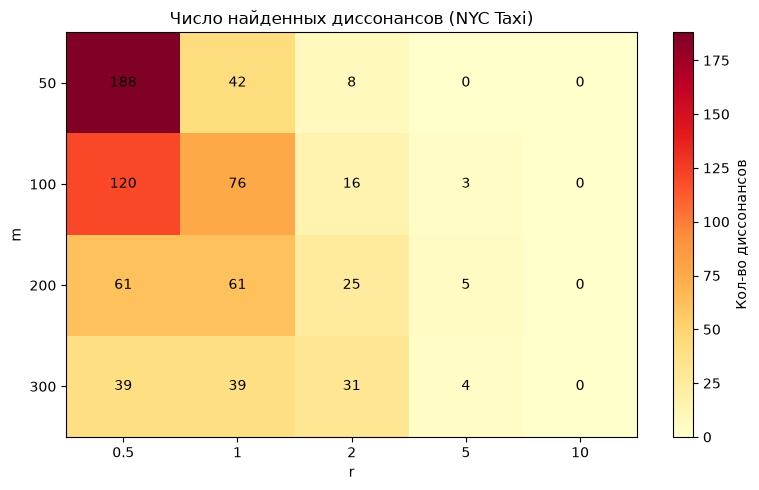

In [32]:
m_values_taxi = [50, 100, 200, 300]
r_values_taxi = [0.5, 1, 2, 5, 10]

counts_taxi = run_drag_experiment(nyc_taxi, m_values_taxi, r_values_taxi)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(counts_taxi, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(r_values_taxi)))
ax.set_xticklabels(r_values_taxi)
ax.set_yticks(range(len(m_values_taxi)))
ax.set_yticklabels(m_values_taxi)
ax.set_xlabel('r')
ax.set_ylabel('m')
ax.set_title('Число найденных диссонансов (NYC Taxi)')

for i in range(len(m_values_taxi)):
    for j in range(len(r_values_taxi)):
        ax.text(j, i, counts_taxi[i, j], ha='center', va='center',
                color='black', fontsize=10)

plt.colorbar(im, ax=ax, label='Кол-во диссонансов')
plt.tight_layout()
plt.show()

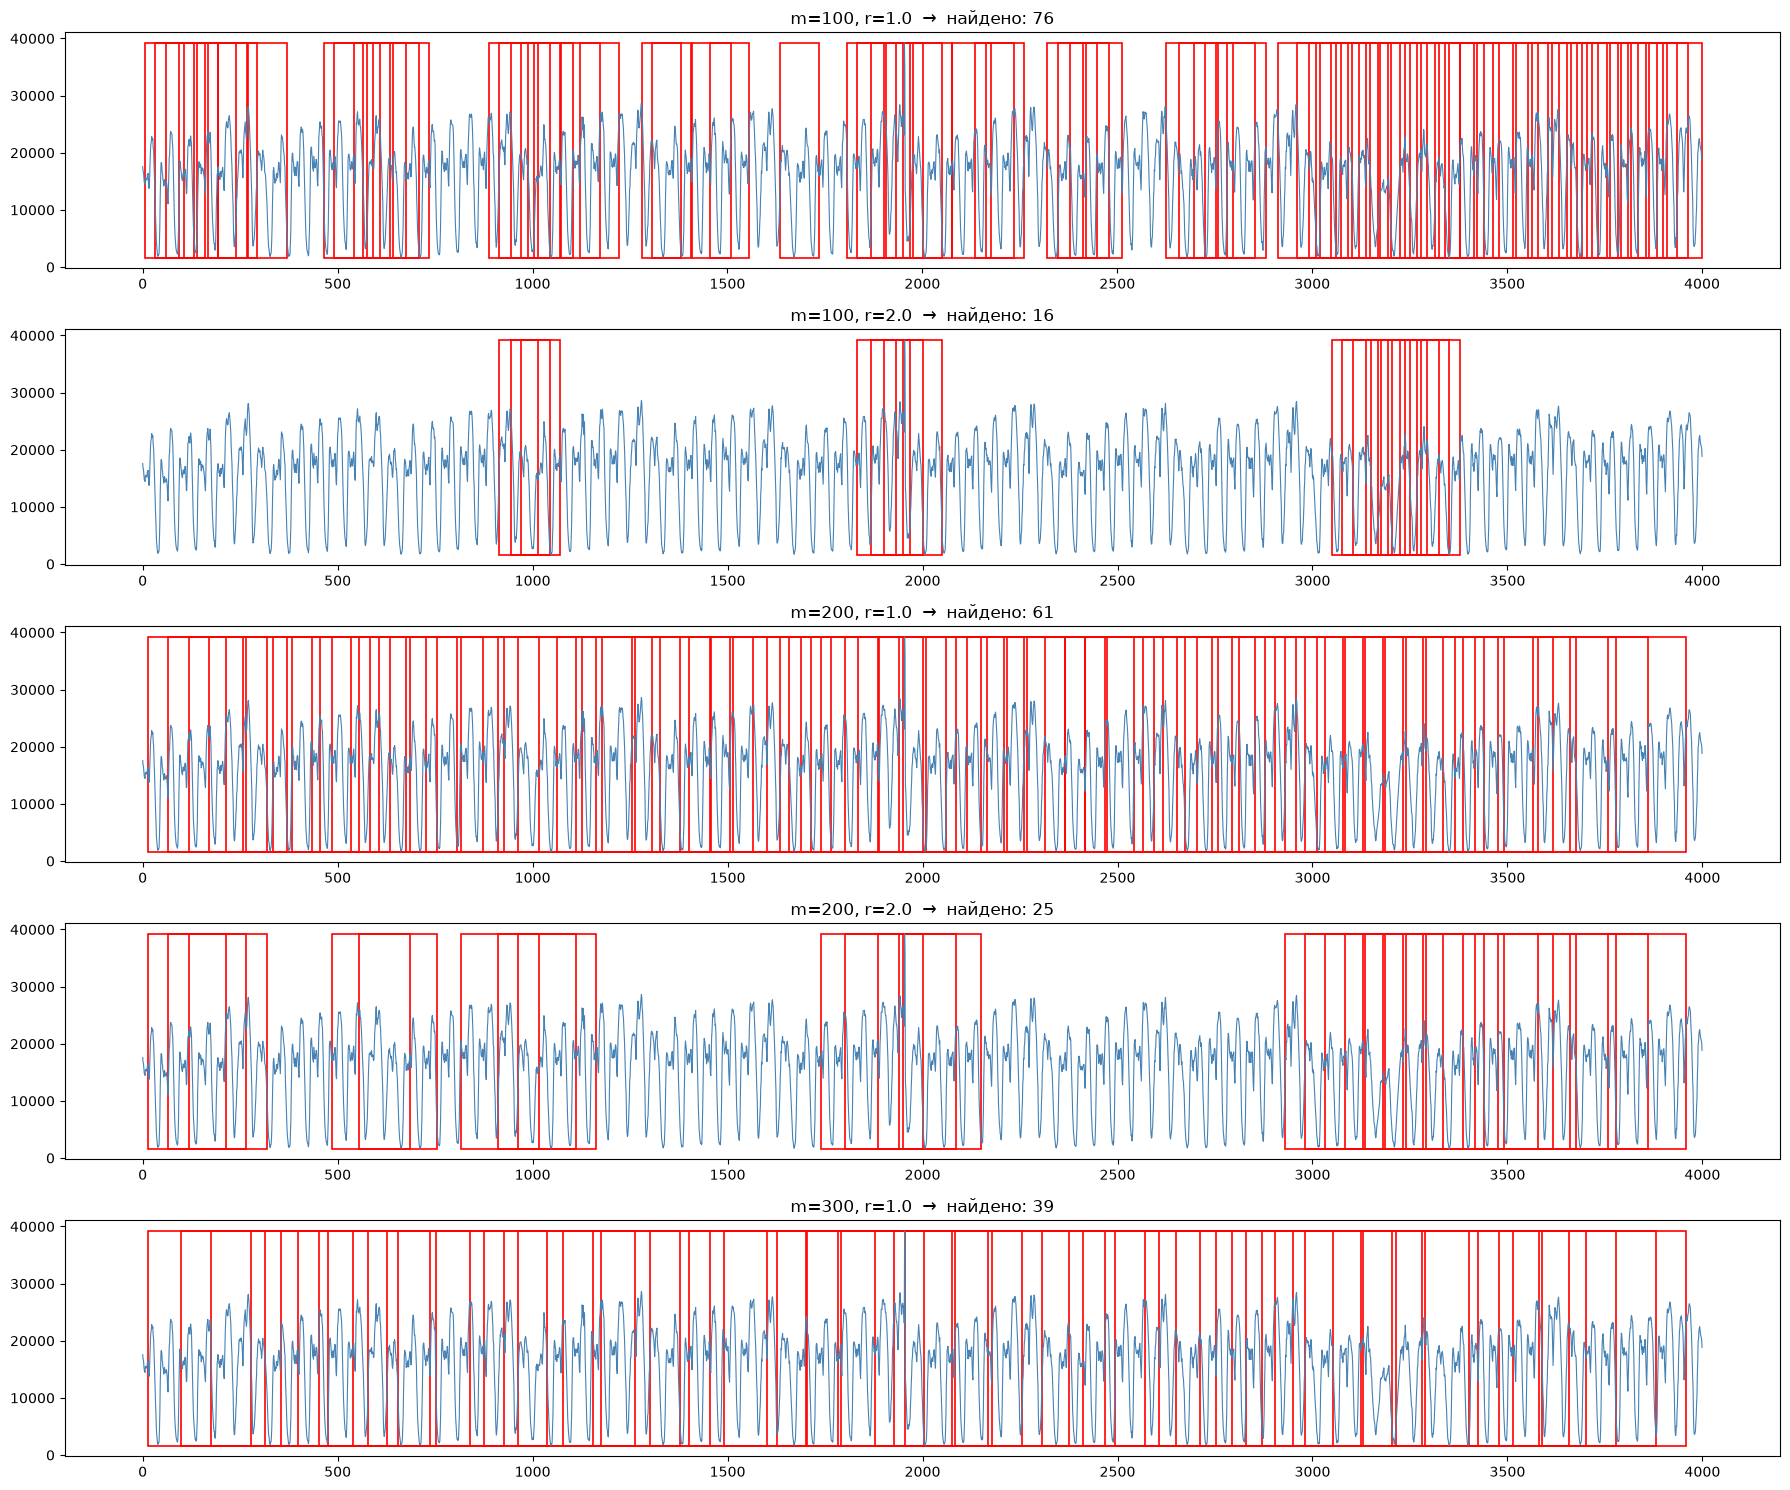

In [33]:
combos_taxi = [(100, 1.0), (100, 2.0), (200, 1.0),
               (200, 2.0), (300, 1.0)]

fig, axes = plt.subplots(nrows=len(combos_taxi), ncols=1,
                         figsize=(18, 3 * len(combos_taxi)))

for ax, (m_, r_) in zip(axes, combos_taxi):
    idxs, _, _ = DRAG(nyc_taxi, m_, r_)
    ax.plot(nyc_taxi, color='steelblue', linewidth=0.8)
    for pos in idxs:
        ax.add_patch(Rectangle(
            (pos, nyc_taxi.min()), m_,
            nyc_taxi.max() - nyc_taxi.min(),
            linewidth=1.2, edgecolor='red', facecolor='none'
        ))
    ax.set_title(f'm={m_}, r={r_}  →  найдено: {len(idxs)}')

plt.tight_layout()
plt.show()

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [43]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [44]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [45]:
maxL

55

In [46]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


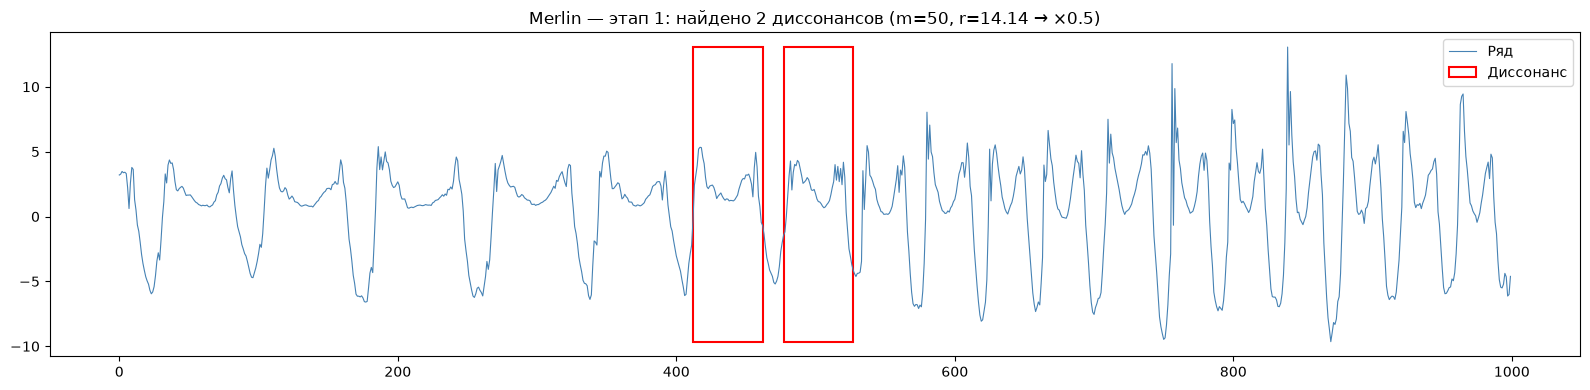

In [47]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(T, color='steelblue', linewidth=0.8, label='Ряд')

for i in range(cound_find_dis):
    pos = int(dis_idx[i])
    ax.add_patch(Rectangle(
        (pos, T.min()), m,
        T.max() - T.min(),
        linewidth=1.5, edgecolor='red', facecolor='none',
        label='Диссонанс' if i == 0 else None
    ))

ax.set_title(f'Merlin — этап 1: найдено {cound_find_dis} диссонансов '
             f'(m={m}, r={2*np.sqrt(m):.2f} → ×0.5)')
ax.legend()
plt.tight_layout()
plt.show()

На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [48]:
# === Второй этап: поиск диссонансов следующих 4 длин ===

# шаг длины (в статье Merlin step обычно 1, но для ускорения можно больше)
step = 1
# сколько длин покрываем на втором этапе
num_lengths_stage2 = 4

for k in range(1, num_lengths_stage2 + 1):
    if cound_find_dis >= topK:
        break

    m_cur = minL + k * step

    # r = 0.99 * nnDist предыдущего найденного диссонанса
    # (берём последний ненулевой nnDist)
    prev_nn = dis_nnDist[cound_find_dis - 1]
    if prev_nn <= 0:
        break
    r = 0.99 * prev_nn

    # Пересоздаём маску, т.к. m_cur изменилась
    include = np.ones(len(T) - m_cur + 1, dtype=bool)
    excl_zone = int(np.ceil(m_cur / 4))

    # Заново исключаем окрестности уже найденных диссонансов
    for i in range(cound_find_dis):
        core.apply_exclusion_zone(include, int(dis_idx[i]), excl_zone, False)

    result = DRAG(data=T, m=m_cur, r=r, include=include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis += 1
        if cound_find_dis >= topK:
            break

print(f'После второго этапа найдено: {cound_find_dis}')


# === Третий этап: поиск диссонансов всех оставшихся длин ===

# Максимальная длина диссонанса. Ограничим, например, N//4 или 500
maxL_final = min(500, len(T) // 2)

m_cur = minL + num_lengths_stage2 * step + 1

while cound_find_dis < topK and m_cur <= maxL_final:
    # берём последние 5 найденных расстояний (или меньше, если есть)
    k_last = min(5, cound_find_dis)
    if k_last < 2:
        # недостаточно данных для статистики — просто уменьшаем r
        r = 0.9 * r
    else:
        last_dists = dis_nnDist[cound_find_dis - k_last:cound_find_dis]
        mu = last_dists.mean()
        sigma = last_dists.std()
        r = mu - 2 * sigma
        if r <= 0:
            r = 0.5 * last_dists.min()  # защита от отрицательного r

    include = np.ones(len(T) - m_cur + 1, dtype=bool)
    excl_zone = int(np.ceil(m_cur / 4))

    for i in range(cound_find_dis):
        core.apply_exclusion_zone(include, int(dis_idx[i]), excl_zone, False)

    result = DRAG(data=T, m=m_cur, r=r, include=include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis += 1
        if cound_find_dis >= topK:
            break

    # увеличиваем длину (можно шагом 1, но для ускорения — 5 или 10)
    m_cur += step

print(f'После третьего этапа найдено: {cound_find_dis}')

print(f'Итог: найдено {cound_find_dis} диссонансов из {topK}')

После второго этапа найдено: 2
После третьего этапа найдено: 10
Итог: найдено 10 диссонансов из 10


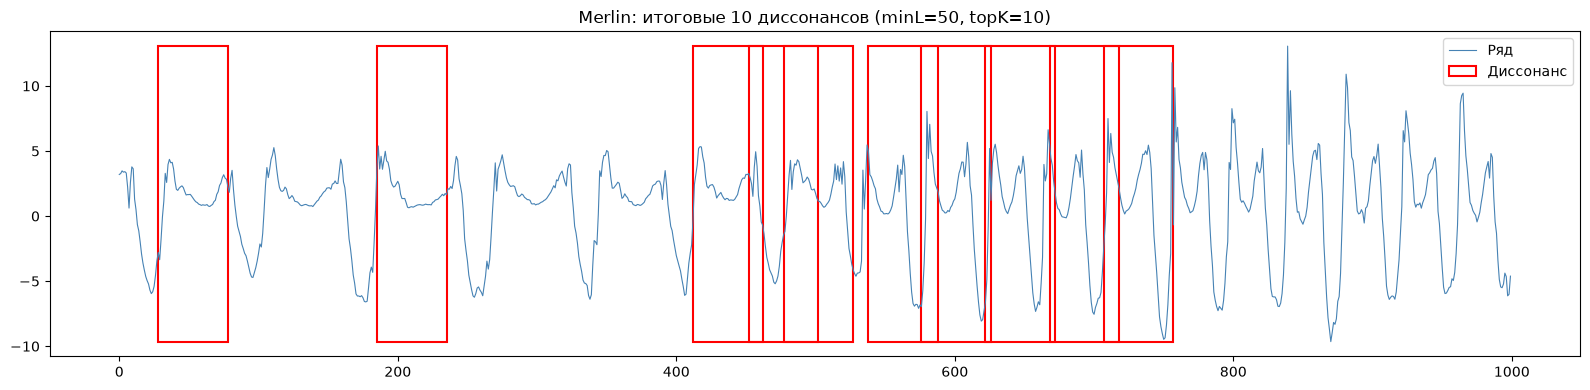

In [40]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(T, color='steelblue', linewidth=0.8, label='Ряд')

# Разные цвета для разных этапов можно различить по длине диссонанса
for i in range(cound_find_dis):
    pos = int(dis_idx[i])
    # длина диссонанса неизвестна явно, но мы помним её из цикла — упрощённо m
    ax.add_patch(Rectangle(
        (pos, T.min()), m,
        T.max() - T.min(),
        linewidth=1.5, edgecolor='red', facecolor='none',
        label='Диссонанс' if i == 0 else None
    ))

ax.set_title(f'Merlin: итоговые {cound_find_dis} диссонансов '
             f'(minL={minL}, topK={topK})')
ax.legend()
plt.tight_layout()
plt.show()

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


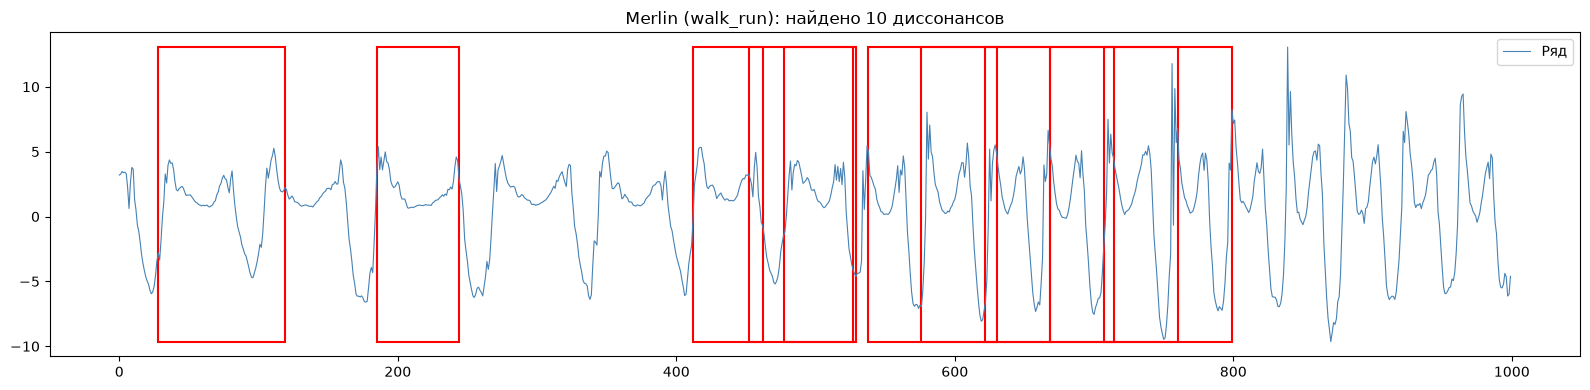

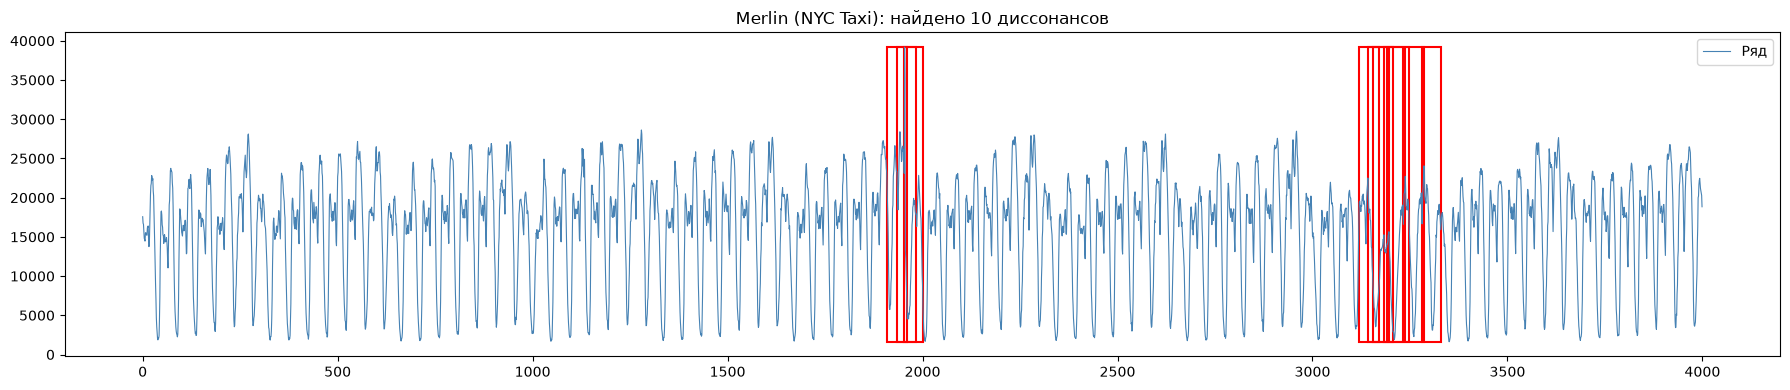

In [ ]:
def merlin(series, minL, topK=10, step=1, maxL=None):
    T = series
    if maxL is None:
        maxL = min(500, len(T) // 2)

    dis_idx = -np.ones(topK)
    dis_nnDist = -np.ones(topK)
    dis_nn_idx = np.full(topK, -np.inf)
    dis_len = -np.ones(topK)

    include = np.ones(len(T) - minL + 1, dtype=bool)
    excl_zone = int(np.ceil(minL / 4))

    r = 2 * np.sqrt(minL)
    m_cur = minL
    found = 0
    stage = 1

    while found < topK and m_cur <= maxL:
        # ---------- выбор r ----------
        if stage == 1:
            # первый этап — фиксированный r, уменьшается если не нашли
            r_use = r
        elif stage == 2:
            # второй этап — r = 0.99 * nnDist предыдущего
            r_use = 0.99 * dis_nnDist[found - 1]
        else:
            # третий этап — r = μ - 2σ по последним 5
            k_last = min(5, found)
            if k_last < 2:
                r_use = 0.9 * r
            else:
                last = dis_nnDist[found - k_last:found]
                r_use = last.mean() - 2 * last.std()
                if r_use <= 0:
                    r_use = 0.5 * last.min()

        # ---------- пересоздаём include под текущую длину ----------
        include = np.ones(len(T) - m_cur + 1, dtype=bool)
        excl_zone = int(np.ceil(m_cur / 4))
        for i in range(found):
            core.apply_exclusion_zone(include, int(dis_idx[i]), excl_zone, False)

        # ---------- ищем ----------
        result = DRAG(data=T, m=m_cur, r=r_use, include=include)
        for diss, nnDist, nn in zip(*result):
            dis_idx[found] = diss
            dis_nnDist[found] = nnDist
            dis_nn_idx[found] = nn
            dis_len[found] = m_cur
            core.apply_exclusion_zone(include, diss, excl_zone, False)
            found += 1
            if found >= topK:
                break

        # ---------- переход между этапами ----------
        if stage == 1:
            if found > 0:
                stage = 2
                m_cur = minL + step
                stage2_end = minL + 4 * step
            else:
                r *= 0.5   # уменьшаем порог и пробуем снова
        elif stage == 2:
            m_cur += step
            if m_cur > stage2_end:
                stage = 3
        else:
            m_cur += step

    return dis_idx[:found], dis_nnDist[:found], dis_nn_idx[:found], dis_len[:found]


# --- walk_run ---
idx_w, dist_w, nn_w, len_w = merlin(walk_run, minL=50, topK=10)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(walk_run, color='steelblue', linewidth=0.8, label='Ряд')
for pos, m_ in zip(idx_w, len_w):
    ax.add_patch(Rectangle(
        (pos, walk_run.min()), m_,
        walk_run.max() - walk_run.min(),
        linewidth=1.5, edgecolor='red', facecolor='none'
    ))
ax.set_title(f'Merlin (walk_run): найдено {len(idx_w)} диссонансов')
ax.legend()
plt.tight_layout()
plt.show()


# --- NYC Taxi ---
idx_t, dist_t, nn_t, len_t = merlin(nyc_taxi, minL=50, topK=10)

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(nyc_taxi, color='steelblue', linewidth=0.8, label='Ряд')
for pos, m_ in zip(idx_t, len_t):
    ax.add_patch(Rectangle(
        (pos, nyc_taxi.min()), m_,
        nyc_taxi.max() - nyc_taxi.min(),
        linewidth=1.5, edgecolor='red', facecolor='none'
    ))
ax.set_title(f'Merlin (NYC Taxi): найдено {len(idx_t)} диссонансов')
ax.legend()
plt.tight_layout()
plt.show()

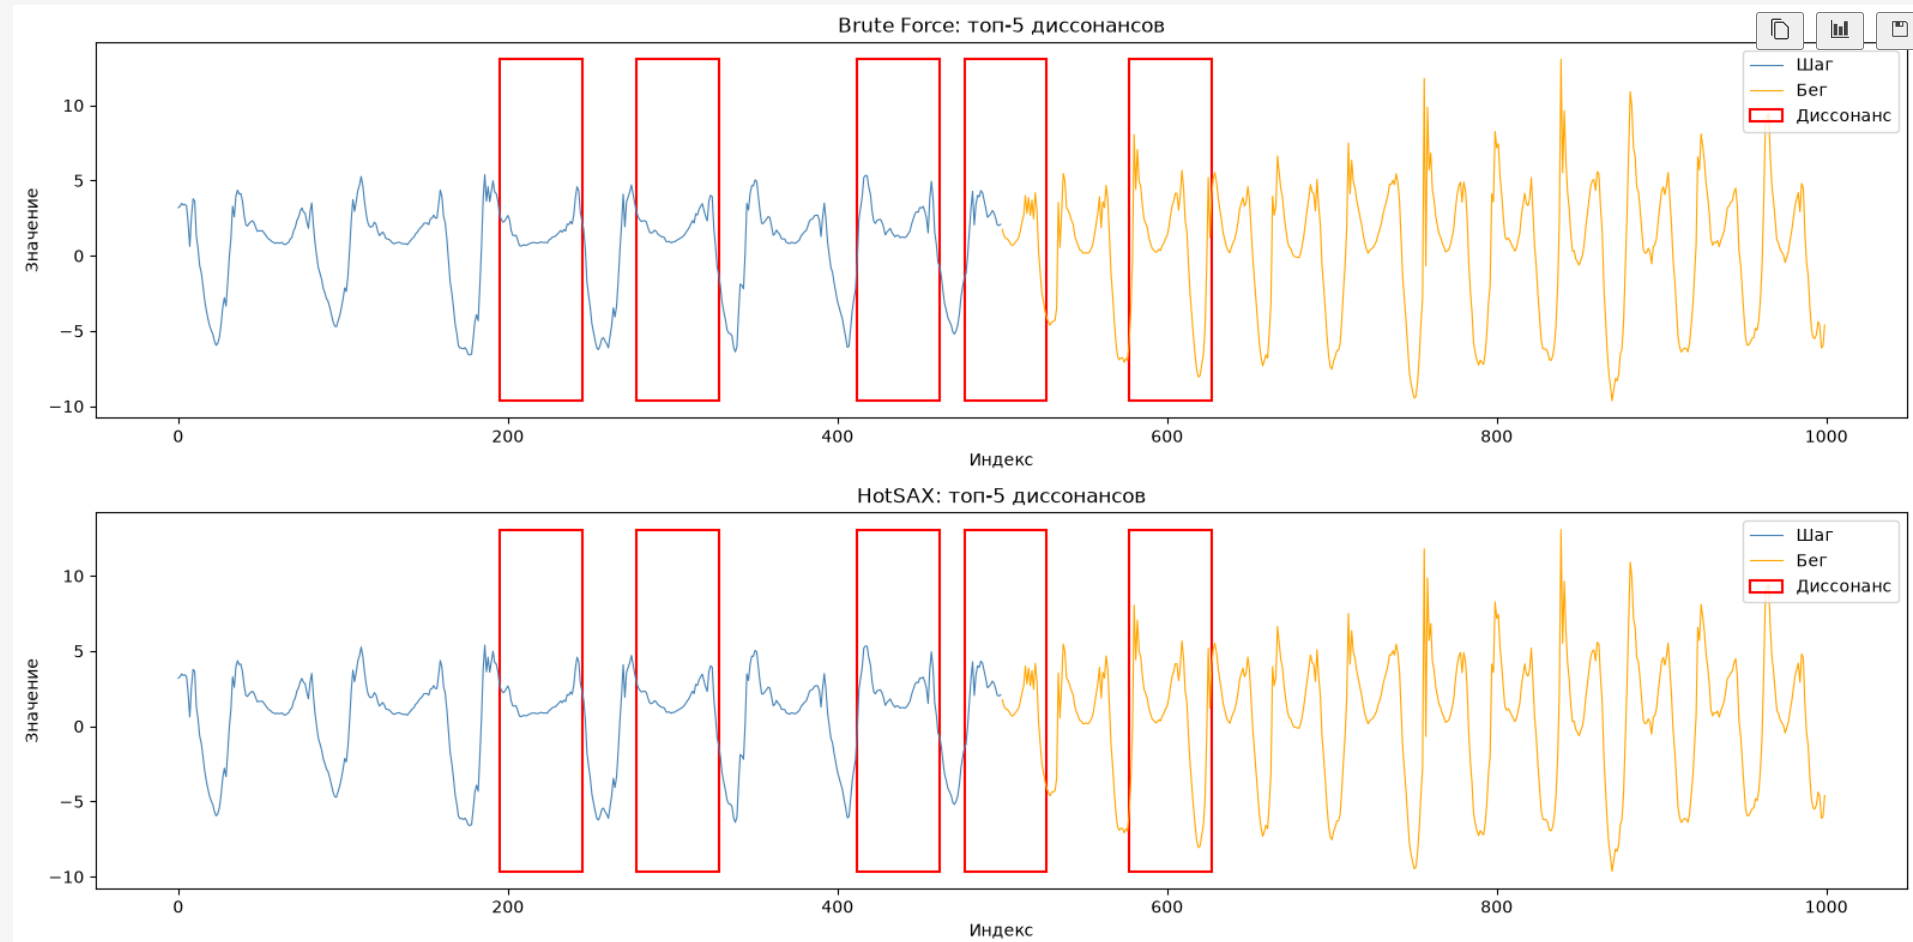

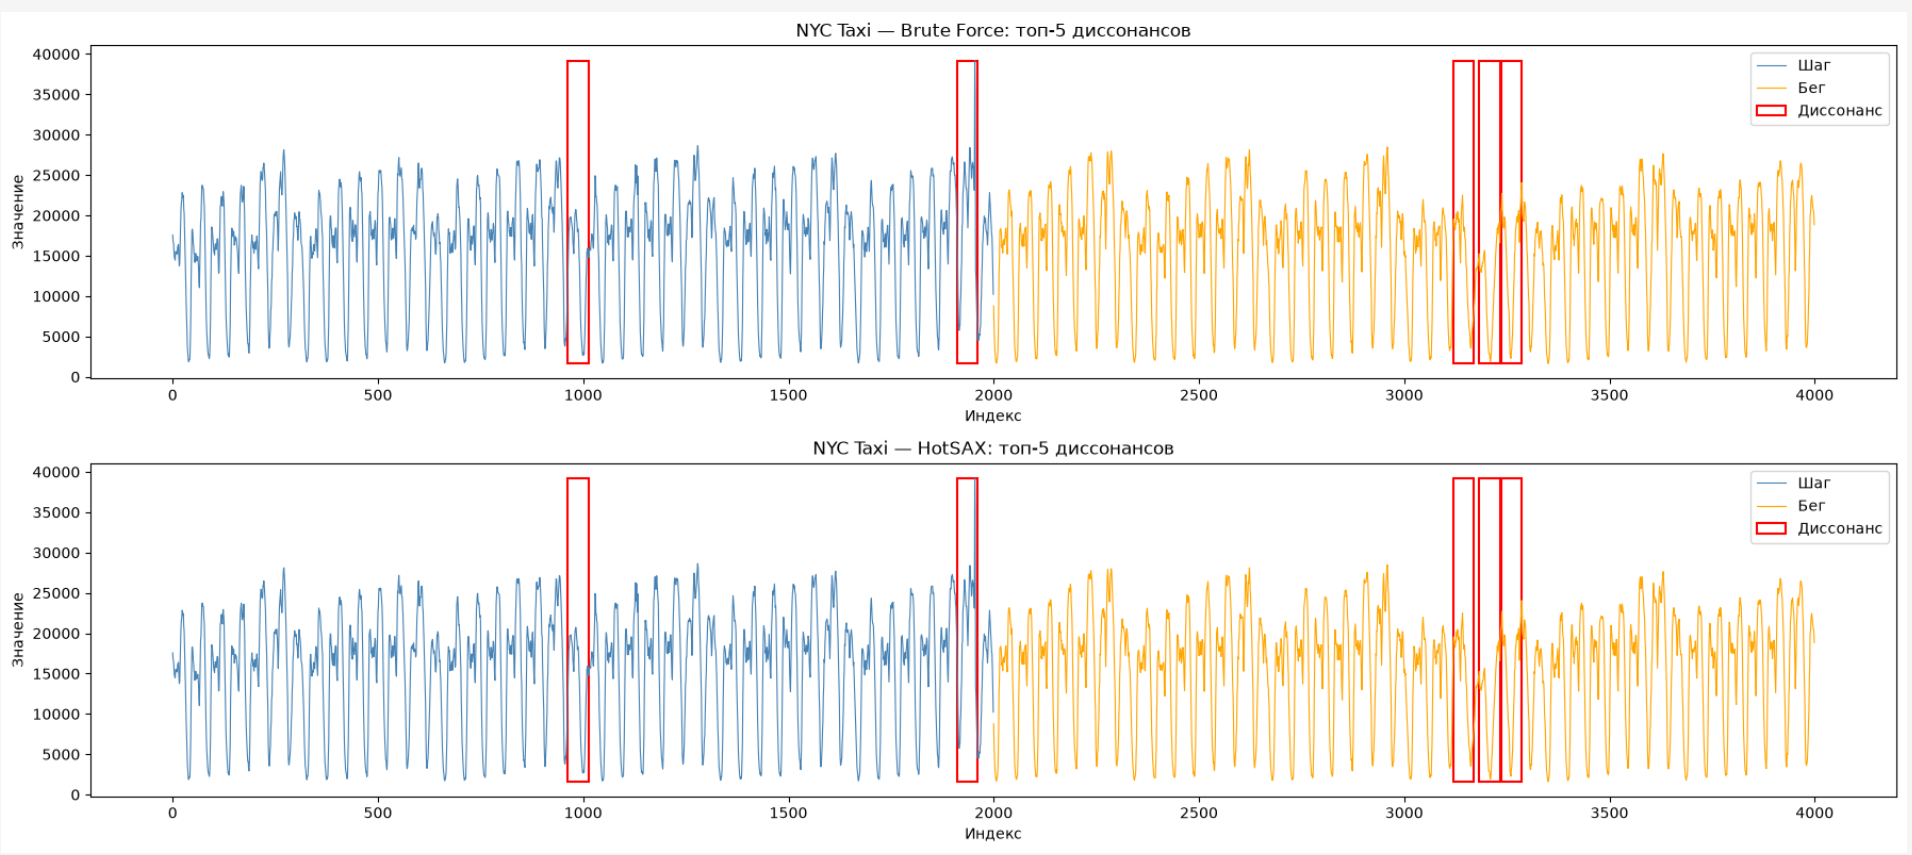